In [1]:
from sklearn.datasets import fetch_california_housing
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import warnings 
warnings.filterwarnings('ignore')

dataset = fetch_california_housing()

#Converting to dataframe
df1 = pd.DataFrame(data=dataset.data,columns=dataset.feature_names)
df2 = pd.DataFrame(data = dataset.target,columns=dataset.target_names)
# df1.head()

#concatiniting df1 and df2
df = pd.concat([df1,df2],axis=1)
df

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847


<Axes: >

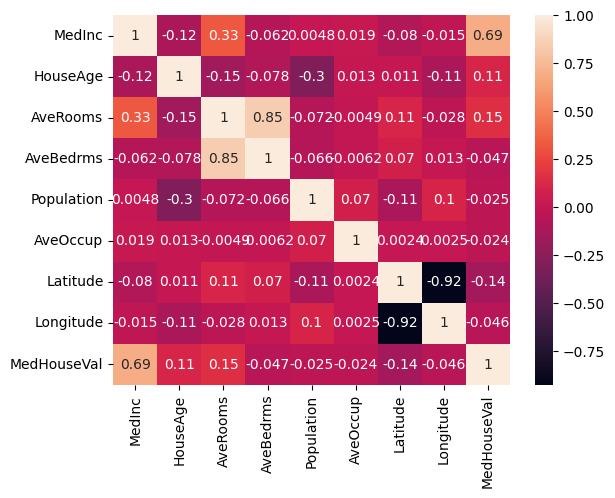

In [3]:
sns.heatmap(df.corr(),annot=True)

In [5]:
## dividing data into independent and dependent feature
x = df1[['MedInc','AveBedrms','Latitude','Longitude']] #independent features
y = df2 #dependent features

In [6]:
x

,MedInc,AveBedrms,Latitude,Longitude
0,8.3252,1.023810,37.88,-122.23
1,8.3014,0.971880,37.86,-122.22
2,7.2574,1.073446,37.85,-122.24
3,5.6431,1.073059,37.85,-122.25
4,3.8462,1.081081,37.85,-122.25
...,...,...,...,...
20635,1.5603,1.133333,39.48,-121.09
20636,2.5568,1.315789,39.49,-121.21
20637,1.7000,1.120092,39.43,-121.22
20638,1.8672,1.171920,39.43,-121.32


In [7]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.33,random_state=10)
print(f"x_train shape: {x_train.shape}, x_test shape: {x_test.shape}")
print(f"y_train shape: {y_train.shape}, y_test shape: {y_test.shape}")

x_train shape: (13828, 4), x_test shape: (6812, 4)
y_train shape: (13828, 1), y_test shape: (6812, 1)


In [8]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [9]:
from sklearn.linear_model import LinearRegression


#creating object
regression = LinearRegression()

#fitting with training data
regression.fit(x_train,y_train)

LinearRegression()

In [10]:
#slope or coefficient
print("Slopes: ",regression.coef_)
##different slopes for each feature

Slopes:  [[ 0.69048398  0.09680723 -1.11230557 -1.06708229]]


In [11]:
#Intercept
regression.intercept_

array([2.06347681])

In [1]:
#prediction for the test data
y_pred = regression.predict(x_test)

NameError: name 'regression' is not defined

# Practice

In [25]:
import seaborn as sns
import pandas as pd 
import matplotlib.pyplot as pyplot
import numpy as np 
import scipy.stats as stat
import pylab

In [4]:
df = sns.load_dataset('titanic')
df.head(2)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False


In [6]:
#checking if there is an any null dataset value in tha df
df.isnull()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
887,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
888,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False
889,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [8]:
df.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [12]:
print(df.shape)
print(df.dropna().shape)
print(f'{891-182} rows lost')

(891, 15)
(182, 15)
709 rows lost


In [16]:
#deleting columns with lots of null values
df.dropna(axis=1)

,survived,pclass,sex,sibsp,parch,fare,class,who,adult_male,alive,alone
0,0,3,male,1,0,7.2500,Third,man,True,no,False
1,1,1,female,1,0,71.2833,First,woman,False,yes,False
2,1,3,female,0,0,7.9250,Third,woman,False,yes,True
3,1,1,female,1,0,53.1000,First,woman,False,yes,False
4,0,3,male,0,0,8.0500,Third,man,True,no,True
...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,0,0,13.0000,Second,man,True,no,True
887,1,1,female,0,0,30.0000,First,woman,False,yes,True
888,0,3,female,1,2,23.4500,Third,woman,False,no,False
889,1,1,male,0,0,30.0000,First,man,True,yes,True


<Axes: xlabel='age', ylabel='Count'>

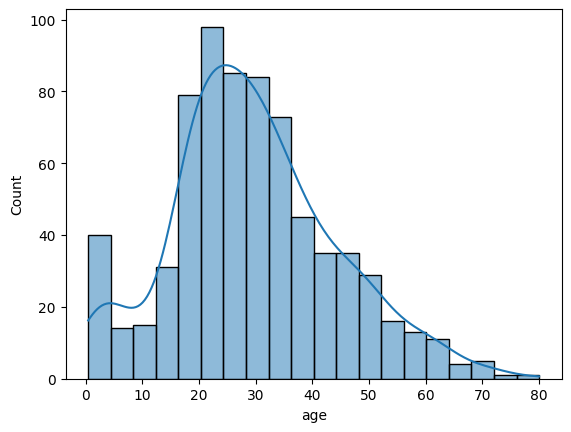

In [17]:
sns.histplot(df['age'],kde=True)

In [27]:
#Categorical dataset replace with mode 
#outlier exist replace with median

<Axes: ylabel='age'>

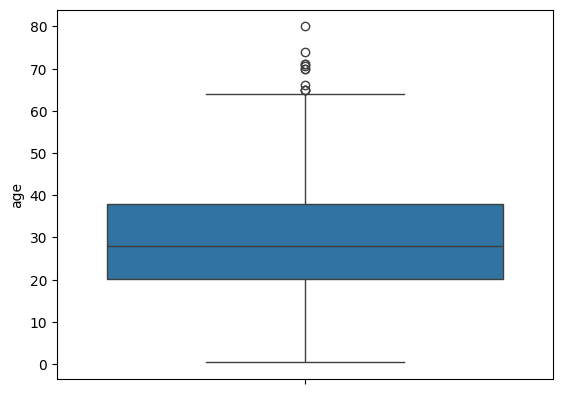

In [28]:
sns.boxplot(df['age'])

In [33]:
df['median_age'] = df['age'].fillna(df['age'].median())

In [39]:
df['embarked'].mode()[0]

'S'

imbalnced data will cause biasness in the model 
to solve this we use 
    upscaling 
    downscaling
    SMOTE 
techniques

In [68]:
np.random.seed(123)
class_0 = pd.DataFrame({
    'feature1': np.random.normal(loc=0,scale=1,size=900),
    'feature2': np.random.normal(loc=0,scale=1,size=900),
    'Target': [0]*900
})
class_1 = pd.DataFrame({
    'feature1': np.random.normal(loc=0,scale=1,size=100),
    'feature2': np.random.normal(loc=0,scale=1,size=100),
    'Target': [1]*100
})
df = pd.concat([class_0,class_1])

In [70]:
df_minority = df[df['Target']==1]
df_majority = df[df['Target']==0]

<Axes: xlabel='feature1', ylabel='Count'>

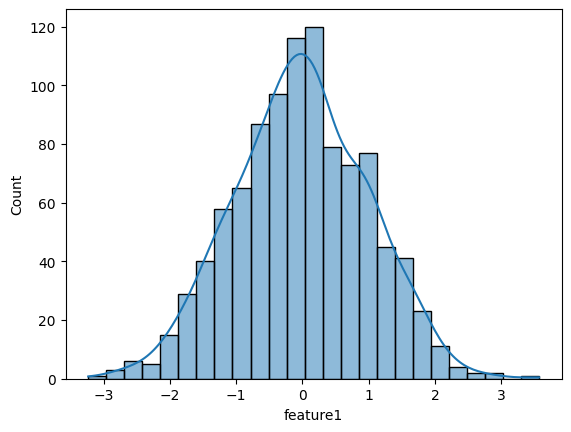

In [54]:
sns.histplot(data=df['feature1'],kde=True)

In [55]:
import matplotlib.pyplot as plt 
import pylab
import scipy.stats as stat

In [60]:
def qqplot(feature):
    plt.subplot(1,2,1) 
    sns.histplot(data=df[feature],kde=True)

    plt.subplot(1,2,2)
    stat.probplot(df[feature],dist='norm',plot=pylab)

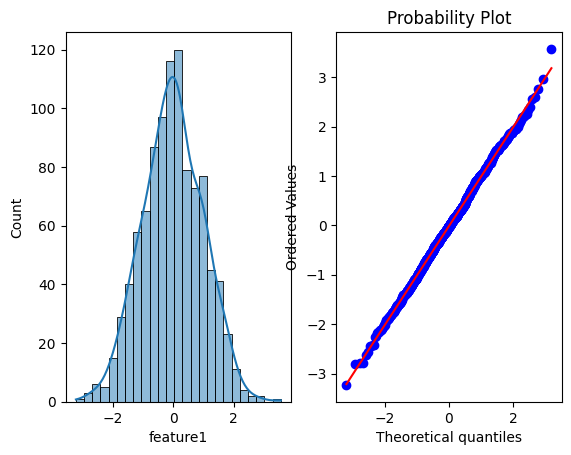

In [61]:
qqplot('feature1')

<Axes: ylabel='feature1'>

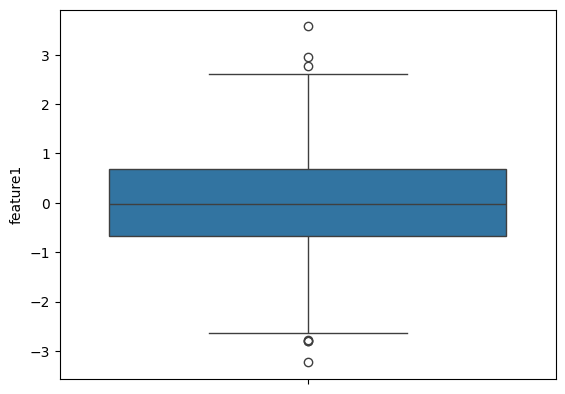

In [66]:
sns.boxplot(df['feature1'])

In [65]:
#upscaling
df_minority=df[df['Target']==1]

In [76]:
#upscaling
from sklearn.utils import resample
df_minority_upscaled = resample(df_minority,
                               replace=True,
                               n_samples = len(df_majority),
                               random_state = 42)
print(df_minority_upscaled.shape)

(900, 3)


In [78]:
#downscaling
df_majority_down = resample(df_majority,
    replace=False,
    n_samples=100,
    random_state=42
)
print(df_majority_down.shape)

(100, 3)


In [81]:
# SMOTE:  synthetic Minority Oversampling Technique
# imblearn.over_sampling
from imblearn.over_sampling import SMOTE


In [82]:
from sklearn.datasets import make_classification
x,y = make_classification(n_samples=1000,
                   n_features=2,
                   n_redundant=0,
                   n_clusters_per_class=1,
                   weights=[0.90],
                   random_state=12)

In [57]:
# making classifications
from sklearn.datasets import make_classification
x,y = make_classification(n_samples=1000,
                         n_features=2,
                         n_classes=2,
                         n_clusters_per_class=1,n_redundant=0,random_state=1023)

In [58]:
import seaborn as sns
import pandas as pd

<Axes: xlabel='0', ylabel='1'>

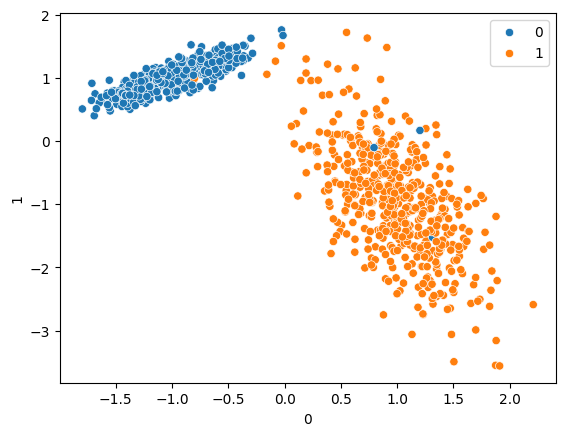

In [59]:
sns.scatterplot(x=pd.DataFrame(x)[0],y=pd.DataFrame(x)[1],hue=y)